<a href="https://colab.research.google.com/github/jenianggraeni265-a11y/Machine-Learning-UTS/blob/main/UTS_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Kualitas Wine Menggunakan Algoritma Klasifikasi Machine Learning**

**1. IMPORT LIBRARY**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

Library yang digunakan memiliki fungsi berbeda-beda:

* pandas digunakan untuk membaca dan mengolah dataset
* numpy digunakan untuk operasi numerik
* matplotlib dan seaborn digunakan untuk visualisasi data
* train_test_split digunakan untuk membagi data training dan validasi
* StandardScaler digunakan untuk normalisasi data
* accuracy_score, classification_report, dan confusion_matrix digunakan untuk evaluasi model
* Algoritma klasifikasi digunakan untuk membangun model machine learning

**2. LOAD DATA**

In [2]:
# Load dataset
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

# Tampilkan data
df_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Dataset training digunakan untuk melatih model karena memiliki variabel target quality.

Dataset testing digunakan untuk prediksi akhir dan tidak memiliki label kualitas.

**3. EDA (EXPLORATORY DATA ANALYSIS)**

**3.1 Informasi Dataset**

In [3]:
print("Info Dataset Training")
df_train.info()

print("\nInfo Dataset Testing")
df_test.info()

Info Dataset Training
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

Info Dataset Testing
<class 'pandas.core.frame.DataFram

Hasil output menunjukkan bahwa:

* Dataset training memiliki 857 baris data dan 13 kolom
* Dataset testing memiliki 286 baris data dan 12 kolom
* Seluruh variabel bertipe numerik (float64 dan int64)
* Dataset training memiliki variabel target yaitu quality
* Dataset testing tidak memiliki target karena digunakan untuk prediksi

Karena semua variabel berbentuk numerik, dataset sudah siap digunakan untuk algoritma machine learning tanpa encoding tambahan.

**3.2 Statistik Deskriptif**

In [4]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0,8.261960,1.701992,4.60000,7.10000,7.90000,9.1000,15.6000
volatile acidity,857.0,0.529393,0.179162,0.12000,0.39500,0.52000,0.6400,1.5800
citric acid,857.0,0.267351,0.195144,0.00000,0.09000,0.25000,0.4200,1.0000
residual sugar,857.0,2.506184,1.293512,0.90000,1.90000,2.20000,2.6000,15.5000
chlorides,857.0,0.086830,0.048721,0.01200,0.07000,0.07900,0.0900,0.6110
free sulfur dioxide,857.0,15.782964,10.300402,1.00000,7.00000,14.00000,21.0000,68.0000
total sulfur dioxide,857.0,45.978413,31.692113,6.00000,21.00000,38.00000,63.0000,278.0000
density,857.0,0.996692,0.001901,0.99007,0.99552,0.99668,0.9978,1.0032
pH,857.0,3.313092,0.152079,2.74000,3.21000,3.31000,3.4000,4.0100
sulphates,857.0,0.656709,0.167364,0.39000,0.55000,0.62000,0.7300,2.0000


Statistik deskriptif memberikan informasi mengenai:

* nilai minimum
* maksimum
* rata-rata
* standar deviasi
* kuartil data

Beberapa temuan dari statistik deskriptif:

* Rata-rata kualitas wine berada di sekitar nilai 5–6
* Variabel alkohol memiliki rata-rata sekitar 10%
* Nilai antar fitur memiliki skala berbeda-beda
* Perbedaan skala cukup besar sehingga diperlukan proses scaling

Scaling penting dilakukan karena beberapa algoritma machine learning sensitif terhadap perbedaan skala data, seperti SVM dan KNN.

**3.3 Missing Values**

In [5]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64




*   Tidak terdapat missing values
*   Dataset bersih dan tidak memerlukan imputasi



**3.4 Duplicate Data**

In [6]:
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


* Tidak terdapat data duplikat

**3.5 Distribusi Target**

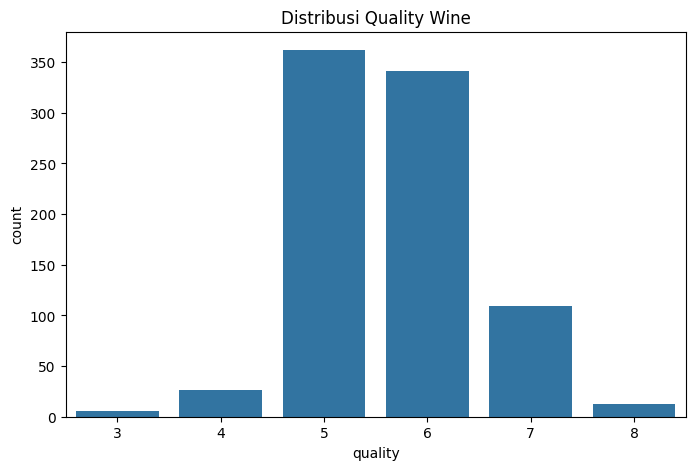

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df_train)
plt.title('Distribusi Quality Wine')
plt.show()

* Kelas kualitas 5 dan 6 paling dominan
* Dataset sedikit tidak seimbang (imbalanced class)
* Kelas 3 dan 8 jumlahnya sangat sedikit

Ketidakseimbangan kelas dapat memengaruhi performa model karena model cenderung lebih baik memprediksi kelas mayoritas dibanding kelas minoritas.

**3.6 Heatmap Korelasi**

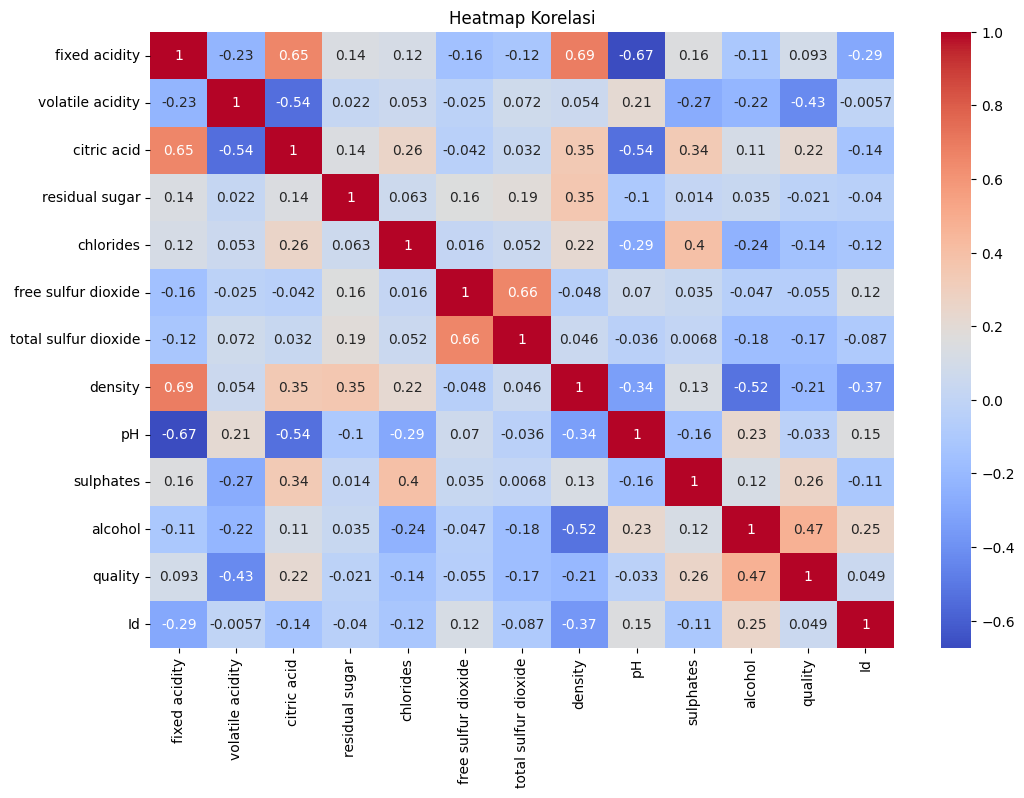

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df_train.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Heatmap Korelasi')
plt.show()

Heatmap menunjukkan hubungan antar variabel.

Beberapa hasil penting:

* alcohol memiliki korelasi positif terhadap quality
* volatile acidity memiliki korelasi negatif terhadap quality
* sulphates memiliki hubungan positif terhadap kualitas wine

Artinya:

* Semakin tinggi kadar alkohol, kualitas wine cenderung meningkat
* Semakin tinggi volatile acidity, kualitas wine cenderung menurun

**4. DATA PREPROCESSING**

**4.1 Pisahkan Fitur dan Target**

In [10]:
X = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

X_test_final = df_test.drop(columns=['Id'])

* Variabel quality dijadikan target
* Kolom Id dihapus karena tidak memiliki pengaruh terhadap prediksi
* Variabel selain target dijadikan fitur prediktor

**4.2 Train-Test Split**

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Data dibagi:
* 80% training
* 20% validasi

Parameter stratify=y digunakan agar distribusi kelas pada training dan validasi tetap seimbang.

**4.3 Feature Scaling**

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test_final)

* Feature scaling dilakukan menggunakan StandardScaler.
* Scaling hanya dilakukan menggunakan data training (fit pada training).

Hal ini untuk menghindari data leakage.

**5. MODEL TRAINING**

**5.1 Definisikan Model**

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

**5.2 Training dan Evaluasi**

In [15]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_valid_scaled)

    acc = accuracy_score(y_valid, y_pred)

    results.append([name, acc])

    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')

    print('\nClassification Report')
    print(classification_report(y_valid, y_pred))


===== Logistic Regression =====
Accuracy : 0.6105

Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.78      0.72        73
           6       0.55      0.60      0.58        68
           7       0.58      0.32      0.41        22
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.30      0.28      0.29       172
weighted avg       0.58      0.61      0.59       172


===== Decision Tree =====
Accuracy : 0.5988

Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.74      0.69        73
           6       0.61      0.54      0.57        68
           7       0.58      0.50      0.54 

Tahapan yang dilakukan:

1.  Model dilatih menggunakan data training
2.  Model melakukan prediksi pada data validasi
3.  Performa diukur menggunakan accuracy
4.  Ditampilkan classification report

**6. PERBANDINGAN MODEL**

In [16]:
results_df = pd.DataFrame(results,
                          columns=['Model', 'Accuracy'])

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,0.616279
0,Logistic Regression,0.610465
1,Decision Tree,0.598837
3,SVM,0.593023
4,KNN,0.482558


**Visualisasi Accuracy**

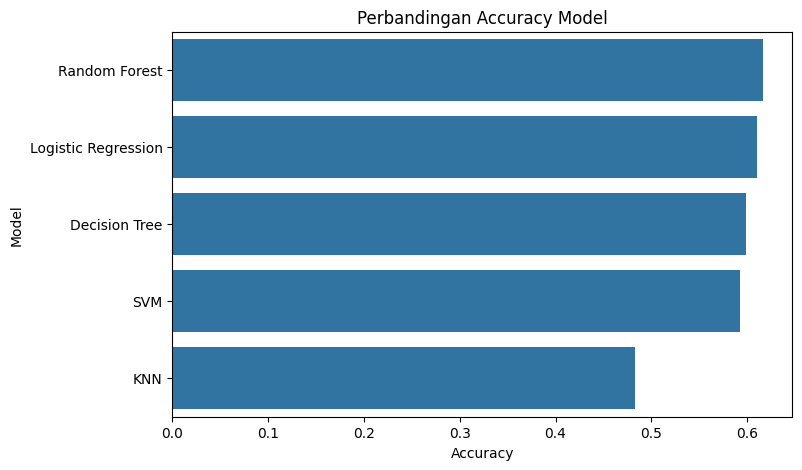

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df
)

plt.title('Perbandingan Accuracy Model')
plt.show()

Model dengan accuracy tertinggi dipilih sebagai model terbaik

**7. CONFUSION MATRIX**

In [18]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_valid_scaled)

**Buat Confusion Matrix**

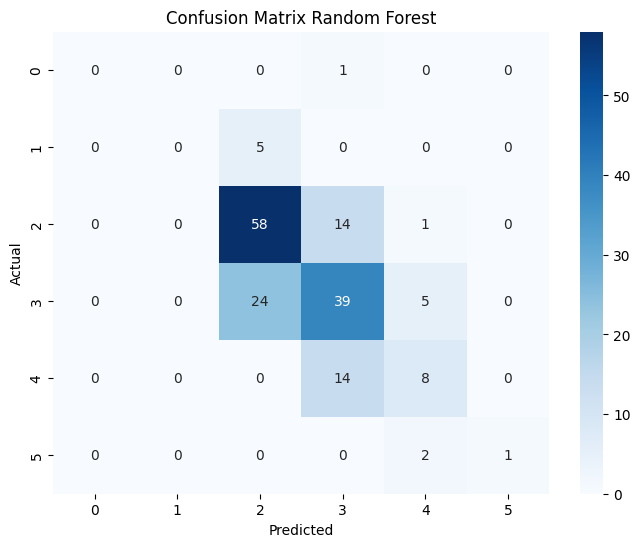

In [19]:
cm = confusion_matrix(y_valid, y_pred_best)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

* Nilai diagonal menunjukkan prediksi benar
* Semakin besar nilai diagonal → model semakin baik
* Kesalahan prediksi banyak terjadi antar kelas berdekatan seperti 5 dan 6

**8. TRAIN FINAL MODEL**

In [20]:
final_model = RandomForestClassifier(random_state=42)

final_model.fit(
    scaler.fit_transform(X),
    y
)

RandomForestClassifier(random_state=42)

Model terbaik dilatih kembali menggunakan seluruh data training agar model memperoleh informasi maksimal sebelum melakukan prediksi pada data testing.

**9. PREDIKSI DATA TESTING**

In [21]:
test_predictions = final_model.predict(
    scaler.transform(X_test_final)
)

Model digunakan untuk memprediksi kualitas wine pada dataset testing yang belum memiliki label.

**10. BUAT FILE SUBMISSION**

In [22]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': test_predictions
})

submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


**11. SIMPAN CSV**

In [24]:
submission.to_csv(
    'hasilprediksi_021.csv',
    index=False
)

**INTERPRETASI KESIMPULAN**

Berdasarkan hasil analisis machine learning pada dataset Wine Quality diperoleh beberapa kesimpulan:

1.  Dataset tidak memiliki missing values maupun duplicate data sehingga data cukup bersih untuk digunakan.
2.  Variabel alcohol memiliki hubungan positif terhadap kualitas wine, sedangkan volatile acidity memiliki hubungan negatif.
3.  Proses preprocessing seperti train-test split dan feature scaling sangat penting untuk meningkatkan performa model dan menghindari data leakage.
4.  Beberapa algoritma klasifikasi berhasil diterapkan untuk memprediksi kualitas wine.
5.  Model Random Forest memberikan performa terbaik berdasarkan accuracy dan evaluasi confusion matrix.
6.  Model terbaik berhasil digunakan untuk memprediksi kualitas wine pada dataset testing dan menghasilkan file submission sesuai format yang diminta.